In [82]:
%matplotlib inline
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.model_selection import cross_val_score
from sklearn.metrics import classification_report, matthews_corrcoef, confusion_matrix
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import roc_curve, RocCurveDisplay, auc, roc_auc_score

In [2]:
import pandas as pd
import numpy as np
from rdkit import Chem
from rdkit.Chem import Draw
from rdkit.Chem import AllChem
from rdkit import DataStructs
from rdkit.Chem import Descriptors
from rdkit.Chem import rdMolDescriptors
from rdkit.Chem import MACCSkeys

In [3]:
import matplotlib.pyplot as plt

In [4]:
df = pd.read_csv("final_total", sep=' ', na_values=['na'])
df = df.dropna(ignore_index=True)
df

,CHEMBLID,smiles,ido_ic50,tdo_ic50
0,CHEMBL1098875,O=C1c2cc(F)ccc2-n2c1nc1ccccc1c2=O,23.0,60.0
1,CHEMBL1209728,Cc1c(Br)oc2c1C(=O)C(=O)c1c-2ccc2c1CCCC2(C)C,10000.0,10000.0
2,CHEMBL1276265,O=C1c2ccc(Cl)cc2-n2c1nc1ccccc1c2=O,183.0,224200.0
3,CHEMBL1346056,Oc1ccccc1-c1nc2c3ccccc3c3ccccc3c2[nH]1,11790.0,12250.0
4,CHEMBL139935,O=[N+]([O-])c1cc(F)c2cccnc2c1O,14610.0,30230.0
...,...,...,...,...
755,CHEMBL5221020,O[C@@H]1CCCC[C@H]1CNc1c(Br)ccc2[nH]ncc12,1230.0,11240.0
756,CHEMBL5221102,Brc1cc(NC[C@H]2CCCN2)c2cn[nH]c2c1,56450.0,7450.0
757,CHEMBL578036,CC1(C)CCCc2c1ccc1c2C(=O)C(=O)c2c(CO)coc2-1,10000.0,450.0
758,CHEMBL584991,Nc1nonc1/C(=N/O)Nc1ccc(F)c(Cl)c1,50.0,10000.0


In [5]:
df_class = pd.read_csv("ido_tdo.csv" , index_col=0)
df_class

,ido_tdo
0,AA
1,II
2,AI
3,II
4,II
...,...
755,II
756,II
757,IA
758,AI


In [6]:
y = df_class.values.reshape(len(df),)
y

array(['AA', 'II', 'AI', 'II', 'II', 'II', 'IA', 'II', 'II', 'II', 'IA',
       'II', 'AI', 'II', 'II', 'II', 'II', 'II', 'II', 'II', 'II', 'II',
       'II', 'II', 'II', 'II', 'II', 'II', 'II', 'II', 'II', 'II', 'II',
       'II', 'II', 'II', 'II', 'II', 'II', 'II', 'II', 'II', 'II', 'AI',
       'II', 'II', 'II', 'II', 'II', 'II', 'II', 'IA', 'IA', 'II', 'AA',
       'IA', 'II', 'II', 'AI', 'IA', 'AI', 'IA', 'II', 'II', 'IA', 'II',
       'II', 'IA', 'IA', 'IA', 'IA', 'AA', 'IA', 'AA', 'IA', 'IA', 'IA',
       'IA', 'IA', 'IA', 'IA', 'II', 'AI', 'II', 'II', 'II', 'AI', 'AI',
       'AI', 'AI', 'AI', 'AI', 'AI', 'AI', 'AI', 'AI', 'AI', 'II', 'AI',
       'AA', 'AI', 'II', 'AI', 'AI', 'AI', 'AI', 'AI', 'AI', 'AI', 'AI',
       'II', 'AI', 'AI', 'II', 'AI', 'AA', 'AA', 'AA', 'AA', 'AA', 'AA',
       'AA', 'AA', 'II', 'AA', 'AA', 'IA', 'AA', 'AI', 'II', 'AA', 'AA',
       'AI', 'II', 'AA', 'IA', 'AI', 'II', 'II', 'AI', 'AA', 'AI', 'AA',
       'AA', 'AA', 'AA', 'AI', 'II', 'AI', 'AA', 'A

In [7]:
from sklearn.preprocessing import LabelEncoder
encoder = LabelEncoder()

In [8]:
y_label = encoder.fit_transform(y)

In [9]:
y_label

array([0, 3, 1, 3, 3, 3, 2, 3, 3, 3, 2, 3, 1, 3, 3, 3, 3, 3, 3, 3, 3, 3,
       3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 1,
       3, 3, 3, 3, 3, 3, 3, 2, 2, 3, 0, 2, 3, 3, 1, 2, 1, 2, 3, 3, 2, 3,
       3, 2, 2, 2, 2, 0, 2, 0, 2, 2, 2, 2, 2, 2, 2, 3, 1, 3, 3, 3, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 3, 1, 0, 1, 3, 1, 1, 1, 1, 1, 1, 1, 1,
       3, 1, 1, 3, 1, 0, 0, 0, 0, 0, 0, 0, 0, 3, 0, 0, 2, 0, 1, 3, 0, 0,
       1, 3, 0, 2, 1, 3, 3, 1, 0, 1, 0, 0, 0, 0, 1, 3, 1, 0, 0, 0, 1, 0,
       3, 1, 0, 0, 1, 0, 2, 0, 0, 0, 1, 0, 0, 1, 1, 3, 0, 0, 3, 0, 0, 3,
       0, 1, 2, 1, 0, 0, 0, 0, 2, 2, 1, 0, 1, 0, 3, 0, 0, 0, 0, 0, 3, 0,
       0, 1, 1, 2, 0, 0, 0, 1, 0, 0, 3, 1, 1, 2, 0, 3, 3, 0, 0, 3, 0, 3,
       0, 3, 3, 3, 0, 0, 0, 1, 1, 1, 1, 0, 2, 0, 3, 0, 0, 0, 1, 1, 1, 0,
       1, 0, 0, 0, 3, 0, 3, 3, 3, 2, 2, 0, 1, 0, 2, 3, 0, 0, 1, 0, 0, 0,
       3, 3, 0, 0, 3, 3, 1, 2, 3, 0, 3, 0, 2, 0, 1, 3, 1, 0, 0, 3, 3, 0,
       0, 2, 1, 0, 3, 0, 3, 3, 0, 3, 3, 1, 1, 3, 3,

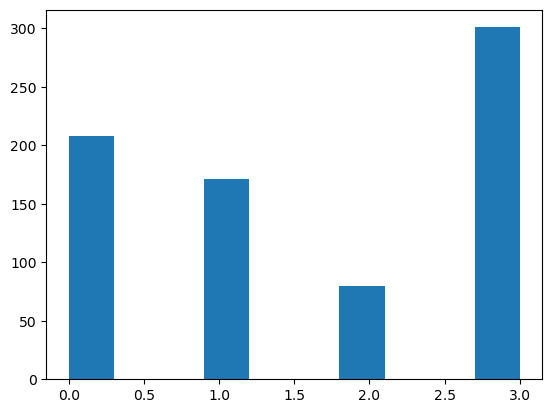

In [10]:
plt.hist(y_label)
plt.show()

In [11]:
from rdkit.Chem import SaltRemover as sr
remover = sr.SaltRemover()

In [12]:
mols = []
for i in range(len(df)):
    try:
        mol_i = Chem.MolFromSmiles(df['smiles'][i])
        if mol_i is None:
            print(f"[WARNING] Invalid SMILES at index {i}, skipping.")
            mols.append(None)  # Maintain indexing for multiprocessing
            continue
        mol_i = remover.StripMol(mol_i, dontRemoveEverything=True)
        mols.append(mol_i)
    except Exception as e:
        print(e)
len(mols)

760

In [13]:
smiles_list = [df['smiles'][i] for i in range(len(df['smiles']))]

In [ ]:
#Deprecated method for Morgan as ExplicitBitVect
FPs = [AllChem.GetMorganFingerprintAsBitVect(mols[i], radius=3, nBits=1024) for i in range(len(mols))]

In [14]:
#Morgan Fingerprints:
fpgen2 = AllChem.GetMorganGenerator(fpSize=1024)
i = 0
l2 = np.zeros((1, 1024), dtype='uint8')
for mol in mols:
    fp2 = fpgen2.GetFingerprintAsNumPy(mols[i])
    l2 = np.vstack((l2, fp2))
    i += 1
MFPs = l2[1:, :]
MFPs.shape

(760, 1024)

In [15]:
MFPs

array([[0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       ...,
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0]], dtype=uint8)

In [69]:
x_train, x_test, y_train, y_test = train_test_split(MFPs, y_label, test_size=0.2, random_state=42, stratify=y_label)
x_test.shape

(152, 1024)

In [70]:
x_train.shape

(608, 1024)

In [51]:
from sklearn.model_selection import GridSearchCV

In [96]:
model = RandomForestClassifier(class_weight='balanced')
params = {'criterion': ['gini', 'entropy'],  'max_depth': list(range(3, 20)), 'max_features': ['sqrt', 'log2', None], 'bootstrap': [True, False]}
grid = GridSearchCV(model, params, cv=5, n_jobs=-1)
grid.fit(x_train, y_train)

GridSearchCV(cv=5, estimator=RandomForestClassifier(class_weight='balanced'),
             n_jobs=-1,
             param_grid={'bootstrap': [True, False],
                         'criterion': ['gini', 'entropy'],
                         'max_depth': [3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14,
                                       15, 16, 17, 18, 19],
                         'max_features': ['sqrt', 'log2', None]})

In [97]:
#With 256 dimension
grid.best_estimator_

RandomForestClassifier(class_weight='balanced', max_depth=19)

In [54]:
#With 256 dimension
grid.best_params_

{'bootstrap': False,
 'criterion': 'entropy',
 'max_depth': 14,
 'max_features': 'sqrt'}

In [98]:
model = RandomForestClassifier(class_weight='balanced', max_depth=19)

In [99]:
#With 256 dimension
np.mean(cross_val_score(model, x_train, y_train, cv=5))

0.7550060967348597

In [100]:
#With 256 dimension
model.fit(x_train, y_train)

RandomForestClassifier(class_weight='balanced', max_depth=19)

In [101]:
#With 256 dimension
model.score(x_train, y_train)

0.9983552631578947

In [102]:
#With 256
model.score(x_test, y_test)

0.743421052631579

In [103]:
py_train = model.predict(x_train)

In [104]:
py_test = model.predict(x_test)

In [105]:
#With 256 dimension
print(classification_report(y_test, py_test))

              precision    recall  f1-score   support

           0       0.66      0.74      0.70        42
           1       0.77      0.71      0.74        34
           2       0.58      0.44      0.50        16
           3       0.82      0.85      0.84        60

    accuracy                           0.74       152
   macro avg       0.71      0.68      0.69       152
weighted avg       0.74      0.74      0.74       152



In [106]:
#With 256 dimension
roc_auc_score(y_test, model.predict_proba(x_test), multi_class='ovr', average='macro')

0.8910399058946115

In [107]:
print(matthews_corrcoef(y_test, py_test))

0.6343630835396977


In [108]:
mapping = {'AA': 0, 'AI': 1, 'IA': 2, 'II': 3}
#External test:
df_test = pd.read_csv("test_morganFP_1024.csv")
df_test_class = pd.read_csv("testdata_target.csv")
y_t = df_test_class.iloc[:,-1]
X_t = df_test.iloc[:, :]
yt_pred = model.predict(X_t)
print("RF")
y_t = y_t.map(mapping)
print(classification_report(y_t , yt_pred))
print(confusion_matrix(y_t , yt_pred))
print(roc_auc_score(y_t, model.predict_proba(X_t) , multi_class='ovr'))
print(matthews_corrcoef(y_t, yt_pred))

RF
              precision    recall  f1-score   support

           0       0.00      0.00      0.00         2
           1       0.00      0.00      0.00        27
           2       0.00      0.00      0.00         8
           3       0.67      1.00      0.80        74

    accuracy                           0.67       111
   macro avg       0.17      0.25      0.20       111
weighted avg       0.44      0.67      0.53       111

[[ 0  0  0  2]
 [ 0  0  0 27]
 [ 0  0  0  8]
 [ 0  0  0 74]]
0.6518738214032979
0.0


/home/linu/anaconda3/envs/embedding/lib/python3.12/site-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but RandomForestClassifier was fitted without feature names
  warnings.warn(
/home/linu/anaconda3/envs/embedding/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/home/linu/anaconda3/envs/embedding/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/home/linu/anaconda3/envs/embedding/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1565: 